# Minimal Kelly Skewness PCE

This notebook computes Kelly skewness from the 178 trimmed-mean PCE components.

Formula:

`Kelly skewness = (P90 + P10 - 2*P50) / (P90 - P10)`

The percentiles are weighted by Dallas Fed-style PCE expenditure weights and use one-month, non-annualized component price changes.

In [1]:
import json
import os
import re
import time
import urllib.parse
import urllib.request
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path.cwd()
COMPONENT_FILE = BASE_DIR / "Trimmed_Mean_Components.xlsx"
OUTPUT_DIR = BASE_DIR / "outputs"

START_DATE = pd.Timestamp("1980-01-01")
BEA_URL = "https://apps.bea.gov/api/data"
BEA_TABLES = {
    "prices": "U20404",
    "nominal": "U20405",
    "real": "U20406",
}


def read_bea_key():
    if os.environ.get("BEA_API_KEY"):
        return os.environ["BEA_API_KEY"].strip()
    for line in (BASE_DIR / "API Keys.txt").read_text(encoding="utf-8", errors="ignore").splitlines():
        match = re.match(r"^\s*BEA\s*:\s*(.+?)\s*$", line, flags=re.IGNORECASE)
        if match:
            return match.group(1).strip()
    raise RuntimeError("Set BEA_API_KEY or add a BEA: entry to API Keys.txt")


BEA_API_KEY = read_bea_key()

## 1. Load Components

In [2]:
components = pd.read_excel(COMPONENT_FILE, usecols=[0, 1, 2])
components.columns = ["line_item", "description", "code"]
components = components.dropna(subset=["line_item"]).copy()
components["line_item"] = components["line_item"].astype(int)
components["description"] = components["description"].astype(str).str.strip()
components["code"] = components["code"].astype(str).str.strip()
components = components.sort_values("line_item").reset_index(drop=True)

component_lines = components["line_item"].tolist()
bea_lines = sorted(set(component_lines + [156]))  # line 156 helps fill lines 157/158 after 2001

print(f"{len(component_lines)} components")
components.head()

178 components


,line_item,description,code
0,7,New domestic autos,DNDCRG
1,8,New foreign autos,DNFCRG
2,9,New light trucks,DNWTRG
3,13,Used autos,DNPURG
4,17,Used light trucks,DUTRRG


## 2. Pull BEA Tables

The pull starts one month before `START_DATE` so the first monthly price change can be calculated.

In [3]:
pull_start_year = (START_DATE - pd.DateOffset(months=1)).year
end_year = date.today().year
raw_tables = {}

for label, table_name in BEA_TABLES.items():
    rows = []
    skipped_years = []

    for year in range(pull_start_year, end_year + 1):
        params = {
            "UserID": BEA_API_KEY,
            "method": "GetData",
            "DataSetName": "NIUnderlyingDetail",
            "TableName": table_name,
            "Frequency": "M",
            "Year": str(year),
            "ResultFormat": "JSON",
        }
        url = f"{BEA_URL}?{urllib.parse.urlencode(params)}"

        with urllib.request.urlopen(url, timeout=90) as response:
            payload = json.loads(response.read().decode("utf-8-sig"))

        if payload.get("BEAAPI", {}).get("Error"):
            skipped_years.append(year)
            continue

        data = payload["BEAAPI"]["Results"].get("Data", [])
        if isinstance(data, dict):
            data = [data]
        rows.extend(data)
        time.sleep(0.05)

    raw_tables[label] = pd.DataFrame(rows)

    note = ""
    if skipped_years:
        note = f"; skipped years without monthly data: {min(skipped_years)}-{max(skipped_years)}"
    print(f"{table_name} ({label}): {len(raw_tables[label]):,} rows{note}")

U20404 (prices): 220,232 rows


U20405 (nominal): 221,368 rows


U20406 (real): 92,800 rows; skipped years without monthly data: 1979-2006


## 3. Convert BEA Rows To Monthly Matrices

In [4]:
matrices = {}

for label, raw in raw_tables.items():
    df = raw.copy()
    df["line_item"] = pd.to_numeric(df["LineNumber"], errors="coerce").astype("Int64")
    df["date"] = pd.to_datetime(
        df["TimePeriod"].astype(str).str.replace(
            r"^(\d{4})M(\d{1,2})$", r"\1-\2-01", regex=True
        )
    )
    df["value"] = pd.to_numeric(
        df["DataValue"].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )
    df = df[df["line_item"].isin(bea_lines)]

    matrix = (
        df.pivot_table(index="date", columns="line_item", values="value", aggfunc="first")
        .sort_index()
        .reindex(columns=bea_lines)
    )
    matrix.columns = matrix.columns.astype(int)
    matrices[label] = matrix

prices = matrices["prices"]
nominal = matrices["nominal"]
real = matrices["real"]

## 4. Fill The Tenant-Housing Line Break

In [5]:
split_start = pd.Timestamp("2002-01-01")
aggregate_line = 156
child_lines = [157, 158]

split_values = nominal.loc[nominal.index < split_start, child_lines].dropna().iloc[-1]
split_ratios = split_values / split_values.sum()

for child_line in child_lines:
    fill = prices[child_line].isna() & prices[aggregate_line].notna() & (prices.index >= split_start)
    prices.loc[fill, child_line] = prices.loc[fill, aggregate_line]

    for matrix in [nominal, real]:
        fill = matrix[child_line].isna() & matrix[aggregate_line].notna() & (matrix.index >= split_start)
        matrix.loc[fill, child_line] = matrix.loc[fill, aggregate_line] * split_ratios.loc[child_line]

prices = prices.drop(columns=[aggregate_line], errors="ignore").reindex(columns=component_lines)
nominal = nominal.drop(columns=[aggregate_line], errors="ignore").reindex(columns=component_lines)
real = real.drop(columns=[aggregate_line], errors="ignore").reindex(columns=component_lines)

## 5. Monthly Price Changes And Dallas Fed Weights

In [6]:
calc_start = START_DATE - pd.DateOffset(months=1)
quantity = real.combine_first(nominal / prices)

common_months = prices.index.intersection(quantity.index)
prices = prices.loc[common_months].sort_index()
quantity = quantity.loc[common_months].sort_index()

prices = prices.loc[prices.index >= calc_start]
quantity = quantity.loc[prices.index]

price_changes = prices.pct_change().iloc[1:]

p_lag = prices.shift(1).iloc[1:].to_numpy(dtype=float)
q_current = quantity.iloc[1:].to_numpy(dtype=float)
q_lag = quantity.shift(1).iloc[1:].to_numpy(dtype=float)

weight_1 = q_current * p_lag
weight_1 = weight_1 / weight_1.sum(axis=1, keepdims=True)

weight_2 = q_lag * p_lag
weight_2 = weight_2 / weight_2.sum(axis=1, keepdims=True)

weights = 0.5 * weight_1 + 0.5 * weight_2
weights = weights / weights.sum(axis=1, keepdims=True)
weights = pd.DataFrame(weights, index=price_changes.index, columns=prices.columns)

price_changes = price_changes.loc[price_changes.index >= START_DATE]
weights = weights.loc[price_changes.index]

print(f"Months: {price_changes.index.min():%Y-%m} to {price_changes.index.max():%Y-%m}")
print(f"Max weight-sum error: {(weights.sum(axis=1) - 1).abs().max():.2e}")

Months: 1980-01 to 2026-04
Max weight-sum error: 6.66e-16


## 6. Kelly Skewness

In [7]:
def weighted_percentiles(changes, weights, percentiles=(10, 50, 90)):
    month = pd.DataFrame(
        {
            "price_change": changes.to_numpy(dtype=float) * 100.0,
            "weight": weights.reindex(changes.index).to_numpy(dtype=float),
            "line_item": changes.index.astype(int),
        }
    ).sort_values(["price_change", "line_item"], kind="mergesort")

    month["weight"] = month["weight"] / month["weight"].sum()
    month["cdf"] = month["weight"].cumsum()

    out = {}
    for p in percentiles:
        out[p] = month.loc[month["cdf"] >= p / 100.0, "price_change"].iloc[0]
    return out


rows = []
for month in price_changes.index:
    pct = weighted_percentiles(price_changes.loc[month], weights.loc[month])
    p10, p50, p90 = pct[10], pct[50], pct[90]
    rows.append(
        {
            "date": month,
            "period": month.strftime("%Y-%m"),
            "p10": p10,
            "p50": p50,
            "p90": p90,
            "kelly_skewness": (p90 + p10 - 2 * p50) / (p90 - p10),
        }
    )

kelly = pd.DataFrame(rows).set_index("date")
kelly["kelly_skewness_12m_avg"] = kelly["kelly_skewness"].rolling(12).mean()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
kelly.to_csv(OUTPUT_DIR / "kelly_skewness_minimal.csv")

kelly.tail()

,period,p10,p50,p90,kelly_skewness,kelly_skewness_12m_avg
date,,,,,,
2025-12-01,2025-12,-0.355137,0.270868,0.902834,0.004739,0.005253
2026-01-01,2026-01,-0.390115,0.218631,1.601673,0.388744,0.012583
2026-02-01,2026-02,-0.305363,0.223064,1.151497,0.274568,0.020063
2026-03-01,2026-03,-0.448257,0.284157,1.186354,0.103868,0.073937
2026-04-01,2026-04,-0.414729,0.239867,1.261168,0.218812,0.112782


## 7. Chart

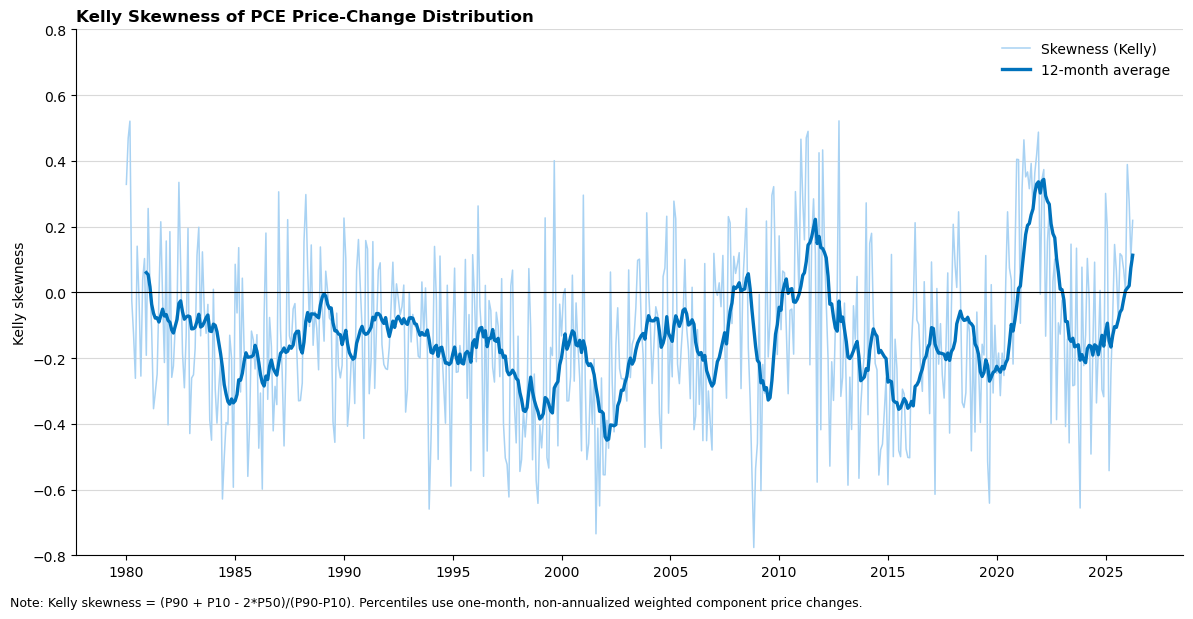

Wrote C:\Users\abour\OneDrive\Economic Research\Inflation\Trimmed Mean PCE\outputs\kelly_skewness_minimal.csv
Wrote C:\Users\abour\OneDrive\Economic Research\Inflation\Trimmed Mean PCE\outputs\kelly_skewness_minimal.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(kelly.index, kelly["kelly_skewness"], color="#A8D2F3", lw=1.1, label="Skewness (Kelly)")
ax.plot(kelly.index, kelly["kelly_skewness_12m_avg"], color="#0072BC", lw=2.4, label="12-month average")

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Kelly Skewness of PCE Price-Change Distribution", loc="left", weight="bold")
ax.set_ylabel("Kelly skewness")
ax.grid(axis="y", color="#D9D9D9")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
ax.set_ylim(-0.8, 0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.02,
    "Note: Kelly skewness = (P90 + P10 - 2*P50)/(P90-P10). Percentiles use one-month, non-annualized weighted component price changes.",
    fontsize=9,
)
fig.tight_layout()

chart_path = OUTPUT_DIR / "kelly_skewness_minimal.png"
fig.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Wrote {OUTPUT_DIR / 'kelly_skewness_minimal.csv'}")
print(f"Wrote {chart_path}")